# 📊 Customer Churn Analysis Project

## 🎯 Objective:
To analyze customer churn, identify key drivers, and provide actionable recommendations to improve customer retention and reduce revenue loss.

## 📂 Data Understanding

In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 🧹 Data Cleaning

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

churn_rate = df["Churn"].mean() * 100
print(churn_rate)

26.578498293515356


### Insight:

The churn rate is approximately 26.5%.

This indicates that around 1 in every 4 customers is leaving the company,
which is a significant concern for the business.

Such a high churn rate can lead to substantial revenue loss and increased customer acquisition costs,
as acquiring new customers is generally more expensive than retaining existing ones.

This highlights the need for the company to identify key drivers of churn and implement targeted retention strategies.

## 📊 Exploratory Data Analysis

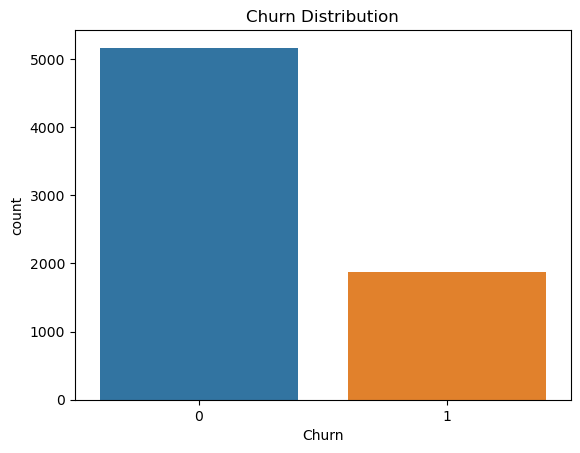

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Insight:

The number of customers who did not churn is significantly higher than those who churned.

However, the number of churned customers is still substantial, indicating that churn is a serious business issue.

This suggests that while most customers stay, a significant portion is leaving, which needs to be addressed.

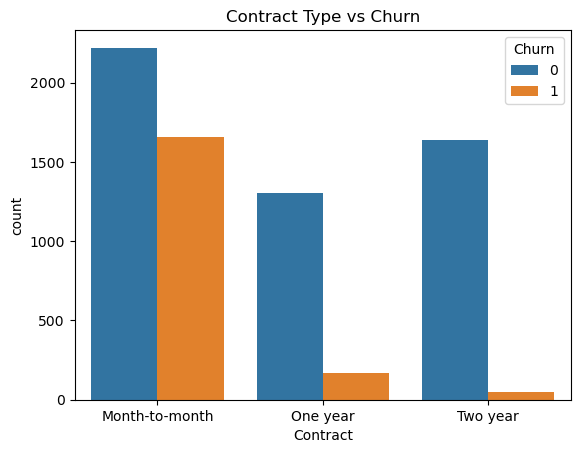

In [10]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

### Insight:

Customers with month-to-month contracts exhibit significantly higher churn compared to those with one-year or two-year contracts.

Churn decreases as the contract duration increases, indicating that long-term customers are more likely to stay with the company.

This suggests that customers on short-term contracts have lower commitment and are more likely to switch to competitors.

The company should encourage customers to shift towards long-term contracts by offering incentives such as discounts or bundled services.

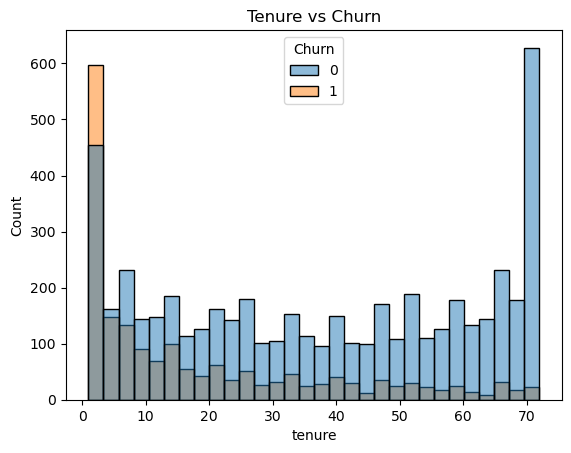

In [12]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=False)
plt.title("Tenure vs Churn")
plt.show()

### Insight:

Customers with low tenure exhibit significantly higher churn, with most churn occurring within the first few months of joining.

As tenure increases, the likelihood of churn decreases substantially, indicating that long-term customers are more loyal and less likely to leave.

This suggests that the initial phase of the customer journey is critical, and poor early experiences may be driving customers to churn.

The company should focus on improving the onboarding process, customer support, and engagement during the initial months to reduce early churn.

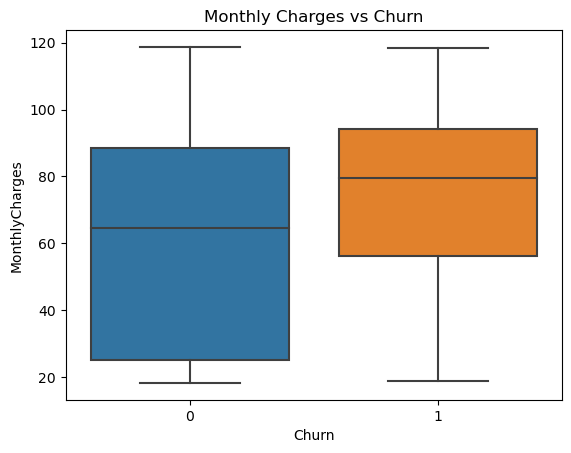

In [14]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Insight:

Customers with higher monthly charges are more likely to churn compared to those with lower charges.

The median monthly charges for churned customers are significantly higher, indicating that pricing may be a key factor influencing customer decisions.

This suggests that customers paying more may have higher expectations and may leave if they do not perceive sufficient value.

The company should evaluate its pricing strategy and ensure that high-paying customers receive adequate value through better services, support, or bundled offerings.

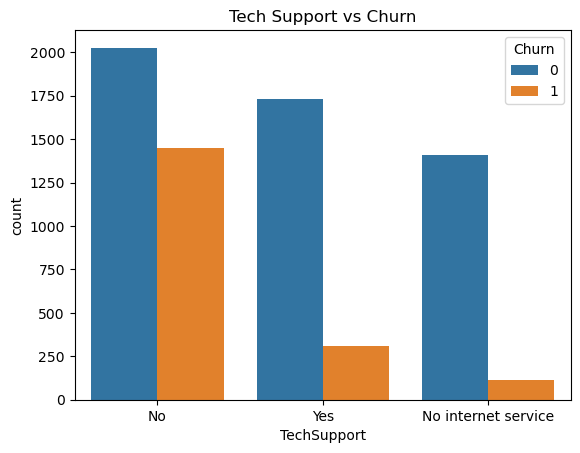

In [15]:
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("Tech Support vs Churn")
plt.show()

### Insight:

Customers who do not have tech support exhibit significantly higher churn compared to those who have access to tech support.

This indicates that the availability of support services plays a crucial role in customer retention.

Customers without support may face unresolved issues, leading to dissatisfaction and eventual churn.

The company should encourage customers to opt for tech support services and improve support quality to enhance customer satisfaction and reduce churn.

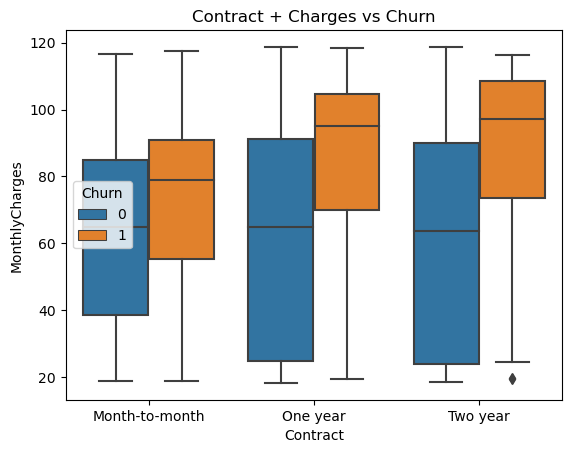

In [16]:
sns.boxplot(x="Contract", y="MonthlyCharges", hue="Churn", data=df)
plt.title("Contract + Charges vs Churn")
plt.show()

### Insight:

Customers with month-to-month contracts and higher monthly charges exhibit the highest churn rates.

In contrast, customers with long-term contracts (one-year or two-year) show significantly lower churn, even when monthly charges are high.

This indicates that contract type and pricing together strongly influence customer retention, with short-term, high-paying customers being the most vulnerable segment.

## 🔍 Key Insights

- Customers on month-to-month contracts have the highest churn
- Most churn occurs in early tenure (0–10 months)
- High-paying customers are more likely to churn
- Lack of tech support increases churn significantly
- High-risk segment: high charges + month-to-month contract

## 💡Recommendation:

The company should target high-risk customers on month-to-month contracts with personalized retention strategies such as discounts, loyalty programs, or incentives to switch to long-term contracts.

Additionally, improving value perception for high-paying customers can help reduce churn in this critical segment.

## 📊 Final Summary

The analysis reveals that customer churn is significantly influenced by contract type, tenure, pricing, and service quality.

Customers on month-to-month contracts exhibit the highest churn, especially when combined with higher monthly charges. In contrast, long-term contract customers demonstrate strong retention.

Churn is also highest during the early stages of the customer lifecycle, indicating that onboarding and initial experience play a crucial role in retention.

Additionally, customers without tech support services are more likely to churn, highlighting the importance of customer support in maintaining satisfaction.

Overall, the most at-risk segment consists of high-paying customers on short-term contracts with limited support.

To reduce churn, the company should focus on improving onboarding, enhancing customer support, optimizing pricing strategies, and encouraging long-term contract adoption.

### 📈 Business Impact:

Reducing churn in high-risk customer segments can significantly improve customer lifetime value and overall profitability.